In [2]:
MOD = 7

class GF49:
    def __init__(self, a, b):
        self.a = a % MOD
        self.b = b % MOD

    def __add__(self, other):
        return GF49(self.a + other.a, self.b + other.b)

    def __sub__(self, other):
        return GF49(self.a - other.a, self.b - other.b)

    def __mul__(self, other):
        # γ² = 6 (mod 7)
        new_a = (self.a * other.a + 6 * self.b * other.b) % MOD
        new_b = (self.a * other.b + self.b * other.a) % MOD
        return GF49(new_a, new_b)

    def __eq__(self, other):
        return self.a == other.a and self.b == other.b

    def __str__(self):
        if self.b == 0:
            return str(self.a)
        if self.a == 0:
            return f"{self.b}γ" if self.b != 1 else "γ"
        if self.b == 1:
            return f"{self.a} + γ"
        return f"{self.a} + {self.b}γ"

    def inverse(self):
        for x in range(MOD):
            for y in range(MOD):
                if self * GF49(x, y) == GF49(1, 0):
                    return GF49(x, y)
        raise ValueError("Обратного нет")

print("Элементы поля GF(7²) (x² + 1):")
for a in range(7):
    for b in range(7):
        print(GF49(a, b))

x = GF49(3, 5)   # 3 + 5γ
y = GF49(4, 6)   # 4 + 6γ
print("\n(3 + 5γ) × (4 + 6γ) =", x * y)

Элементы поля GF(7²) (x² + 1):
0
γ
2γ
3γ
4γ
5γ
6γ
1
1 + γ
1 + 2γ
1 + 3γ
1 + 4γ
1 + 5γ
1 + 6γ
2
2 + γ
2 + 2γ
2 + 3γ
2 + 4γ
2 + 5γ
2 + 6γ
3
3 + γ
3 + 2γ
3 + 3γ
3 + 4γ
3 + 5γ
3 + 6γ
4
4 + γ
4 + 2γ
4 + 3γ
4 + 4γ
4 + 5γ
4 + 6γ
5
5 + γ
5 + 2γ
5 + 3γ
5 + 4γ
5 + 5γ
5 + 6γ
6
6 + γ
6 + 2γ
6 + 3γ
6 + 4γ
6 + 5γ
6 + 6γ

(3 + 5γ) × (4 + 6γ) = 3 + 3γ


In [3]:
MOD = 5

class GF25:
    def __init__(self, a, b):
        self.a = a % MOD
        self.b = b % MOD

    def __add__(self, other):
        return GF25(self.a + other.a, self.b + other.b)

    def __mul__(self, other):
        # γ² = 4γ + 3 (mod 5)
        new_a = (self.a * other.a + 3 * self.b * other.b) % MOD
        new_b = (self.a * other.b + self.b * other.a + 4 * self.b * other.b) % MOD
        return GF25(new_a, new_b)

    def __eq__(self, other):
        return self.a == other.a and self.b == other.b

    def __str__(self):
        if self.b == 0:
            return str(self.a)
        if self.a == 0:
            return f"{self.b}γ" if self.b != 1 else "γ"
        if self.b == 1:
            return f"{self.a} + γ"
        return f"{self.a} + {self.b}γ"

    def inverse(self):
        for x in range(MOD):
            for y in range(MOD):
                candidate = GF25(x, y)
                if self * candidate == GF25(1, 0):
                    return candidate
        raise ValueError("Обратного нет")

# Поиск обратного к 2 + 3γ
x = GF25(2, 3)
inv = x.inverse()
print(f"Элемент: {x}")
print(f"Обратный элемент: {inv}")
print(f"Проверка: {x} × {inv} = {x * inv}")

Элемент: 2 + 3γ
Обратный элемент: 4 + 2γ
Проверка: 2 + 3γ × 4 + 2γ = 1


In [4]:
class GF8:
    def __init__(self, c0, c1, c2):
        self.c0 = c0 % 2
        self.c1 = c1 % 2
        self.c2 = c2 % 2

    def __add__(self, other):
        return GF8(self.c0 ^ other.c0, self.c1 ^ other.c1, self.c2 ^ other.c2)

    def __mul__(self, other):
        a0, a1, a2 = self.c0, self.c1, self.c2
        b0, b1, b2 = other.c0, other.c1, other.c2

        p0 = a0 & b0
        p1 = (a0 & b1) ^ (a1 & b0)
        p2 = (a0 & b2) ^ (a1 & b1) ^ (a2 & b0)
        p3 = (a1 & b2) ^ (a2 & b1)
        p4 = a2 & b2

        # редукция: α³ = α + 1, α⁴ = α² + α
        c0 = p0 ^ p3
        c1 = p1 ^ p3 ^ p4
        c2 = p2 ^ p4
        return GF8(c0, c1, c2)

    def __str__(self):
        terms = []
        if self.c0: terms.append("1")
        if self.c1: terms.append("α")
        if self.c2: terms.append("α²")
        if not terms: return "0"
        return " + ".join(terms)

    def __eq__(self, other):
        return (self.c0 == other.c0 and self.c1 == other.c1 and self.c2 == other.c2)

# Требуемое умножение
x = GF8(1, 1, 1)  # 1 + α + α²
y = GF8(0, 1, 1)  # α + α²

result = x * y
print(f"(1 + α + α²) × (α + α²) = {result}")

(1 + α + α²) × (α + α²) = α²


In [6]:
MOD = 11

class GF11:
    def __init__(self, val):
        self.val = val % MOD

    def __add__(self, other):
        return GF11(self.val + other.val)

    def __sub__(self, other):
        return GF11(self.val - other.val)

    def __mul__(self, other):
        return GF11(self.val * other.val)

    def __truediv__(self, other):
        return self * other.inverse()

    def inverse(self):
        for i in range(1, MOD):
            if (self.val * i) % MOD == 1:
                return GF11(i)
        raise ValueError("Обратного нет")

    def __str__(self):
        return str(self.val)

    def __repr__(self):
        return str(self.val)

# Все обратные элементы
print("Обратные элементы в GF(11):")
for i in range(1, 11):
    elem = GF11(i)
    inv = elem.inverse()
    print(f"{i}⁻¹ = {inv}")

# Специально для 7
seven = GF11(7)
inv7 = seven.inverse()

print(f"\n7⁻¹ = {inv7}")
print(f"Проверка: {seven} × {inv7} = {seven * inv7}")

Обратные элементы в GF(11):
1⁻¹ = 1
2⁻¹ = 6
3⁻¹ = 4
4⁻¹ = 3
5⁻¹ = 9
6⁻¹ = 2
7⁻¹ = 8
8⁻¹ = 7
9⁻¹ = 5
10⁻¹ = 10

7⁻¹ = 8
Проверка: 7 × 8 = 1


In [7]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.3)

In [9]:
Y = np.array([20, 22, 19, 21, 20, 23, 22, 21, 20, 19])

mean_y = np.mean(Y)
var_y = np.var(Y, ddof=0)
std_y = np.std(Y, ddof=0)

print(f"Математическое ожидание M = {mean_y:.2f}")
print(f"Дисперсия D = {var_y:.2f}")
print(f"Среднеквадратическое отклонение σ = {std_y:.2f}")

Математическое ожидание M = 20.70
Дисперсия D = 1.61
Среднеквадратическое отклонение σ = 1.27


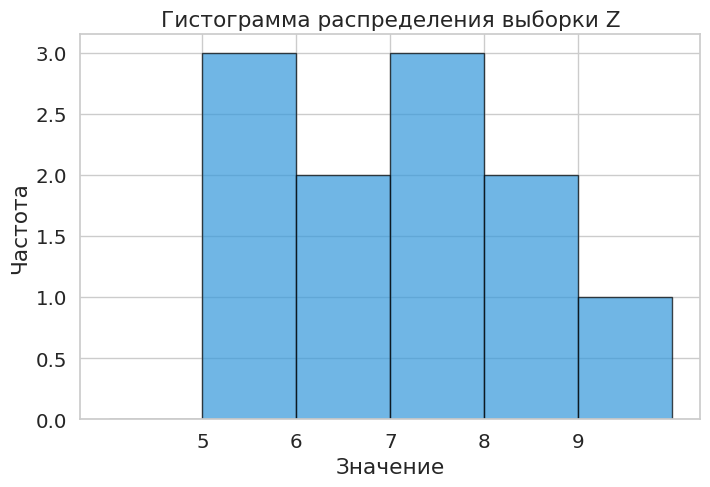

Критерий Шапиро-Уилка
Статистика W = 0.9178, p-value = 0.3009
Гипотеза о нормальности НЕ отвергается (p > 0.05)


In [13]:
Z = np.array([5, 7, 7, 8, 6, 5, 7, 8, 9, 6, 5])

plt.figure(figsize=(8,5))
plt.hist(Z, bins=range(4, 11), edgecolor='black', alpha=0.7, color='#3498db')
plt.title('Гистограмма распределения выборки Z')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.xticks(range(5, 10))
plt.show()

# Проверка нормальности критерием Шапиро-Уилка
stat, p = stats.shapiro(Z)
print("Критерий Шапиро-Уилка")
print(f"Статистика W = {stat:.4f}, p-value = {p:.4f}")
if p > 0.05:
    print("Гипотеза о нормальности НЕ отвергается (p > 0.05)")
else:
    print("Гипотеза о нормальности отвергается (p ≤ 0.05)")

In [14]:
W = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

mean_w = np.mean(W)
std_w = np.std(W, ddof=0)
n = len(W)
confidence = 0.99
df = n - 1

lower, upper = stats.t.interval(confidence, df, loc=mean_w, scale=std_w/np.sqrt(n))

print(f"Среднее = {mean_w:.2f}, СКО = {std_w:.3f}")
print(f"Доверительный интервал для математического ожидания при 99 % доверии:")
print(f"({lower:.3f}, {upper:.3f})")

Среднее = 7.50, СКО = 2.872
Доверительный интервал для математического ожидания при 99 % доверии:
(4.548, 10.452)


In [15]:
A = np.array([10, 12, 14, 16, 18, 20])
B = np.array([5, 6, 7, 8, 9, 10])

# Корреляционный момент (ковариация по формуле лабораторной — деление на n)
R_xy = np.sum((A - np.mean(A)) * (B - np.mean(B))) / len(A)

# Коэффициент корреляции
r = np.corrcoef(A, B)[0,1]

print(f"Корреляционный момент R_xy = {R_xy:.3f}")
print(f"Коэффициент корреляции r = {r:.3f}")

Корреляционный момент R_xy = 5.833
Коэффициент корреляции r = 1.000


In [16]:
V = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

var_v = np.var(V, ddof=0)      # 8.25
std_v = np.std(V, ddof=0)      # ≈2.8723

delta = 0.5          # погрешность Δ
confidence = 0.95
z = stats.norm.ppf(1 - (1-confidence)/2)   # 1.95996 ≈ 1.96

n_required = (z * std_v / delta)**2

print(f"Оценённое среднеквадратическое отклонение σ ≈ {std_v:.4f}")
print(f"Необходимый объём выборки n ≈ {n_required:.1f}")
print("Округляем в большую сторону → n = 127")

Оценённое среднеквадратическое отклонение σ ≈ 2.8723
Необходимый объём выборки n ≈ 126.8
Округляем в большую сторону → n = 127
